In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv(r"seattle-weather.csv")
data.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [3]:
data.shape

(1461, 6)

# Data Exploration

C:\Users\lakpa\AppData\Local\Temp\ipykernel_11232\328620831.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="weather", data=data, palette='hls')


<Axes: xlabel='weather', ylabel='count'>

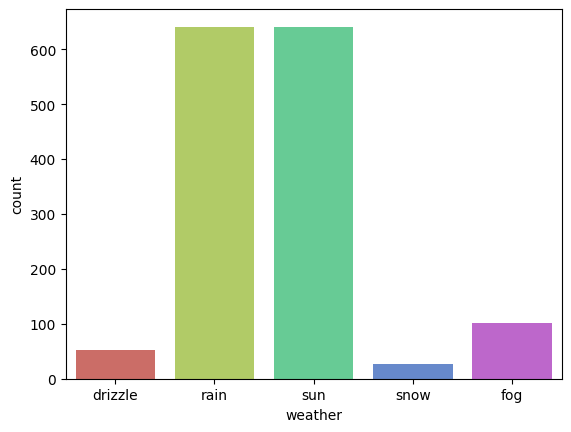

In [7]:
sns.countplot(x="weather", data=data, palette='hls')

In [18]:
countrain = len(data[data.weather=='rain'])
countsun = len(data[data.weather=='sun'])
countdrizzle= len(data[data.weather=='drizzle'])
countsnow = len(data[data.weather =='snow'])
countfog = len(data[data.weather =='fog'])
print(f"Percentage of rain:{(countrain / (len(data.weather))) *100:.2f} %")
print(f"Percentage of sun: {(countsun / (len(data.weather)))*100:.2f}%")
print(f"Percentage of drizzle: {(countdrizzle / (len(data.weather)))*100:.2f}%")
print(f"Percentage of snow: {(countsnow / (len(data.weather)))*100:.2f}%")
print(f"Percentage of fog: {(countfog / (len(data.weather)))*100:.2f}%")

    

Percentage of rain:43.87 %
Percentage of sun: 43.81%
Percentage of drizzle: 3.63%
Percentage of snow: 1.78%
Percentage of fog: 6.91%


In [19]:
# dataset contains the highest amount of data related to 'rain' and 'sun'

In [20]:
data.describe()

,precipitation,temp_max,temp_min,wind
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,3.029432,16.439083,8.234771,3.241136
std,6.680194,7.349758,5.023004,1.437825
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.600000,4.400000,2.200000
50%,0.000000,15.600000,8.300000,3.000000
75%,2.800000,22.200000,12.200000,4.000000
max,55.900000,35.600000,18.300000,9.500000


<Axes: xlabel='wind', ylabel='Count'>

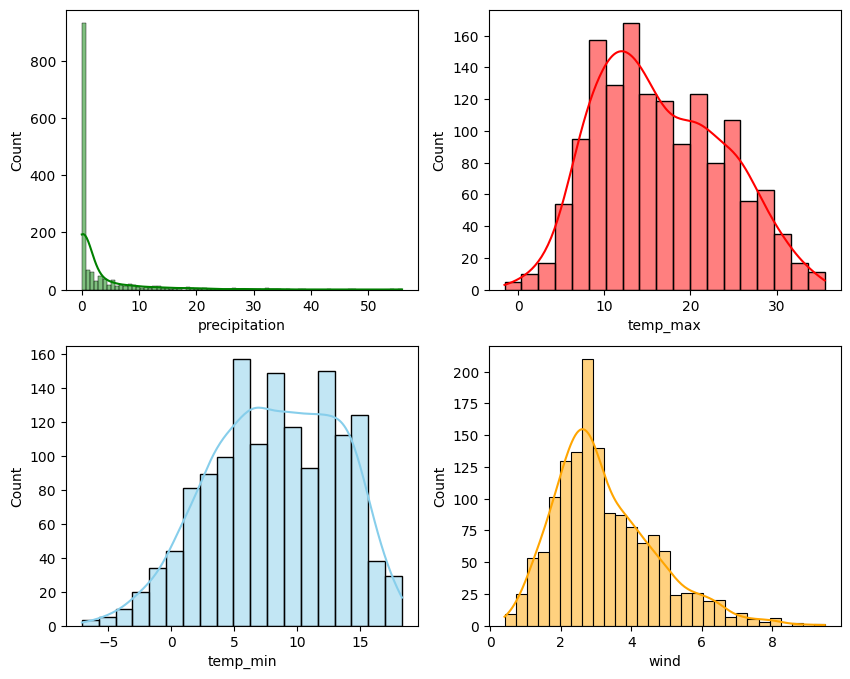

In [25]:
# distribution of numerical data using Histogram 

fig, axes = plt.subplots(2,2, figsize=(10,8))
sns.histplot(data=data, x='precipitation', kde=True, ax=axes[0,0], color='green')
sns.histplot(data=data, x='temp_max',kde=True, ax=axes[0,1], color='red')
sns.histplot(data=data, x='temp_min', kde=True, ax=axes[1,0], color='skyblue')
sns.histplot(data=data, x='wind', kde=True, ax=axes[1,1], color='orange')

In [26]:
# from the above distribution it is clear that 'precipitation', 'wind' are positively skewed
# 'temp_min' is negatively skewed, and both has some outliers

<Axes: xlabel='wind'>

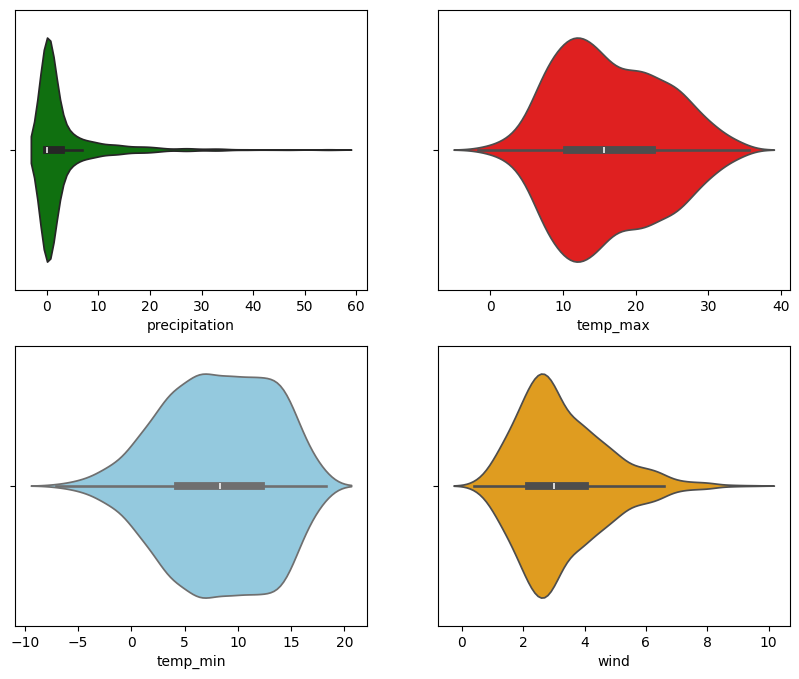

In [29]:
# Violin plot
fig, axes = plt.subplots(2,2, figsize=(10,8))
sns.violinplot(data=data, x='precipitation', ax=axes[0,0], color='green')
sns.violinplot(data=data, x='temp_max', ax=axes[0,1], color='red')
sns.violinplot(data=data, x='temp_min', ax=axes[1,0], color='skyblue')
sns.violinplot(data=data, x='wind', ax=axes[1,1], color='orange')

In [30]:
# from the violin plot we can clearly understand the Skewness of data as the Tail indicates the skewness

# Explore Outliers using Boxplot

<Axes: xlabel='weather', ylabel='precipitation'>

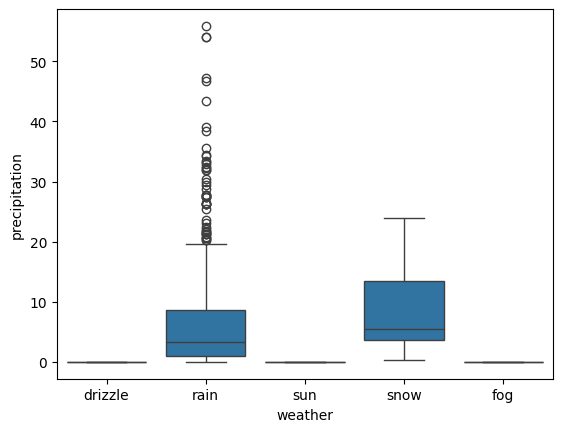

In [34]:
sns.boxplot(data=data, y='precipitation',x = 'weather')

In [35]:
# from the above box plot between 'weather','precipitation' the value of Rain has many outliers
# both 'rain','snow' were positively skewed

<Axes: xlabel='weather', ylabel='temp_max'>

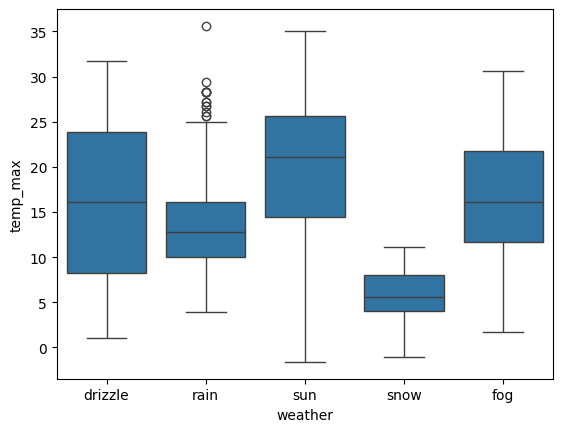

In [37]:
sns.boxplot(data=data, y='temp_max',x='weather')

<Axes: xlabel='weather', ylabel='wind'>

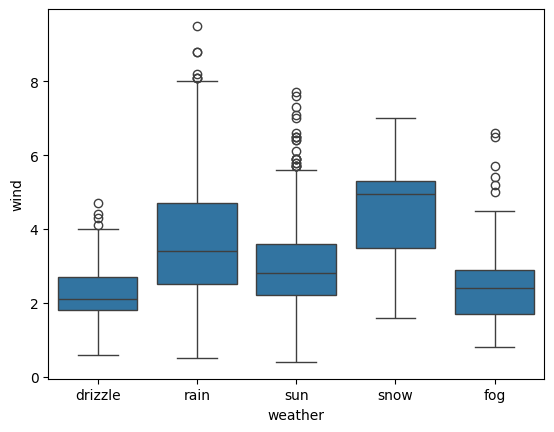

In [39]:
sns.boxplot(data=data, y='wind', x='weather')


In [40]:
# from above boxplot we came to know every attribute of weather has some 'positive outliers'.

<Axes: xlabel='weather', ylabel='temp_min'>

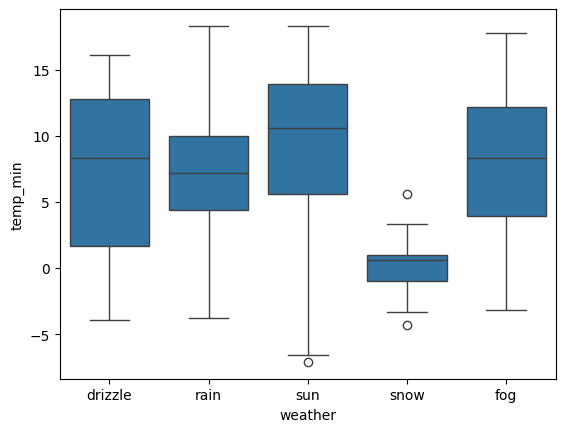

In [42]:
sns.boxplot(data=data, y='temp_min',x='weather')

In [44]:
# drizzle: negative skew, 
# sun: negative skew,some outlier
# snow: negative sknew, some outlliers

<Axes: >

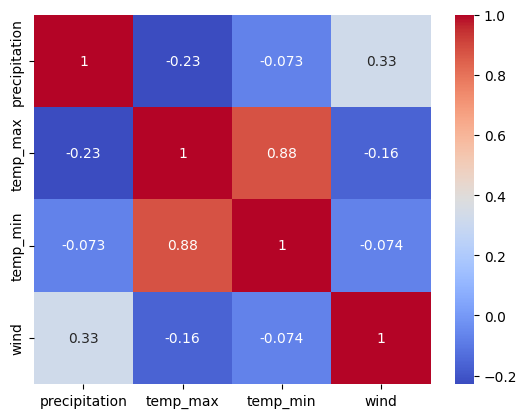

In [47]:
sns.heatmap(data[['precipitation','temp_max','temp_min','wind']].corr(), annot=True, cmap='coolwarm')

In [48]:
# There is a positive correlation between temp_max and temp_min.

<Axes: xlabel='precipitation'>

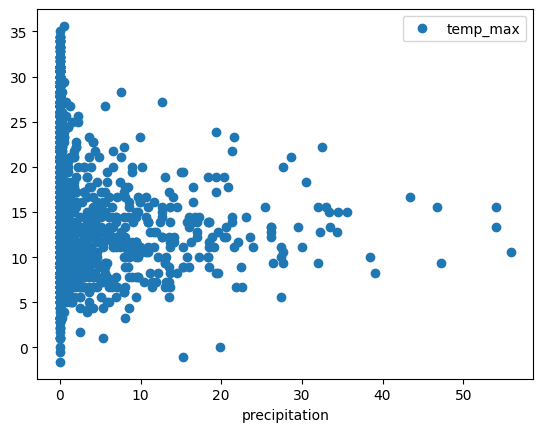

In [50]:
data.plot('precipitation', 'temp_max', style='o')

<Axes: xlabel='wind'>

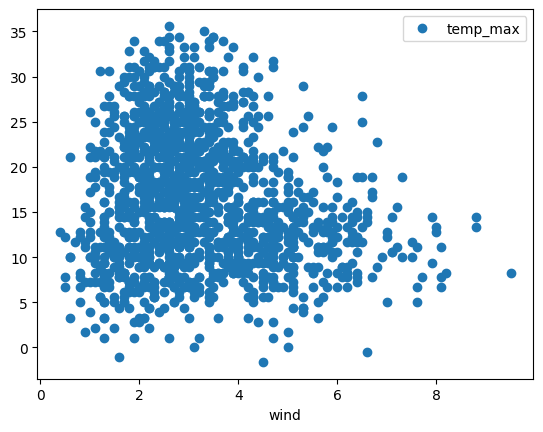

In [51]:
data.plot('wind','temp_max', style='o')

<Axes: xlabel='temp_max'>

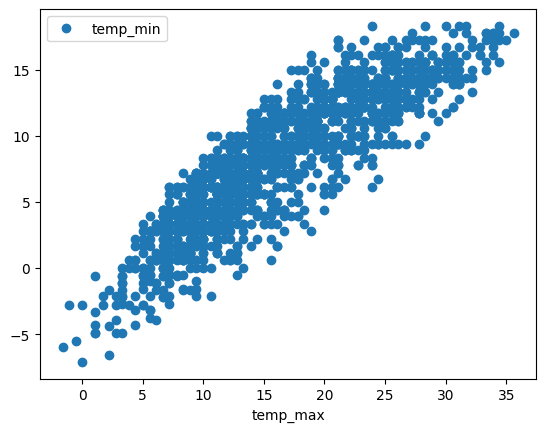

In [52]:
data.plot('temp_max','temp_min', style='o')

In [53]:
data.isna().sum()

date             0
precipitation    0
temp_max         0
temp_min         0
wind             0
weather          0
dtype: int64

# DAta preprocessing

In [85]:
# drop unnecessary variables
df = data.copy()
df.head(2)

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain


In [86]:
df.drop(['date'], axis=1, inplace=True)

In [87]:
df.head(2)

,precipitation,temp_max,temp_min,wind,weather
0,0.0,12.8,5.0,4.7,drizzle
1,10.9,10.6,2.8,4.5,rain


In [93]:
# remove outliers
df_numeric = df.select_dtypes(include = np.number)
q1 = df_numeric.quantile(0.25)
q3 = df_numeric.quantile(0.75)
iqr = q3 - q1
iqr

precipitation     2.8
temp_max         11.6
temp_min          7.8
wind              1.8
dtype: float64

In [94]:
df.shape

(1461, 5)

In [98]:
mask = ~((df_numeric<(q1-1.5*iqr))|(df_numeric>(q3+1.5*iqr))).any(axis=1)
mask.head()


0     True
1    False
2     True
3    False
4     True
dtype: bool

In [99]:
mask.shape

(1461,)

In [100]:
# Apply mask to the original DataFrame
df = df[mask]

In [101]:
df.shape

(1233, 5)

In [102]:
df.head()

,precipitation,temp_max,temp_min,wind,weather
0,0.0,12.8,5.0,4.7,drizzle
2,0.8,11.7,7.2,2.3,rain
4,1.3,8.9,2.8,6.1,rain
5,2.5,4.4,2.2,2.2,rain
6,0.0,7.2,2.8,2.3,rain


<Axes: xlabel='wind', ylabel='Count'>

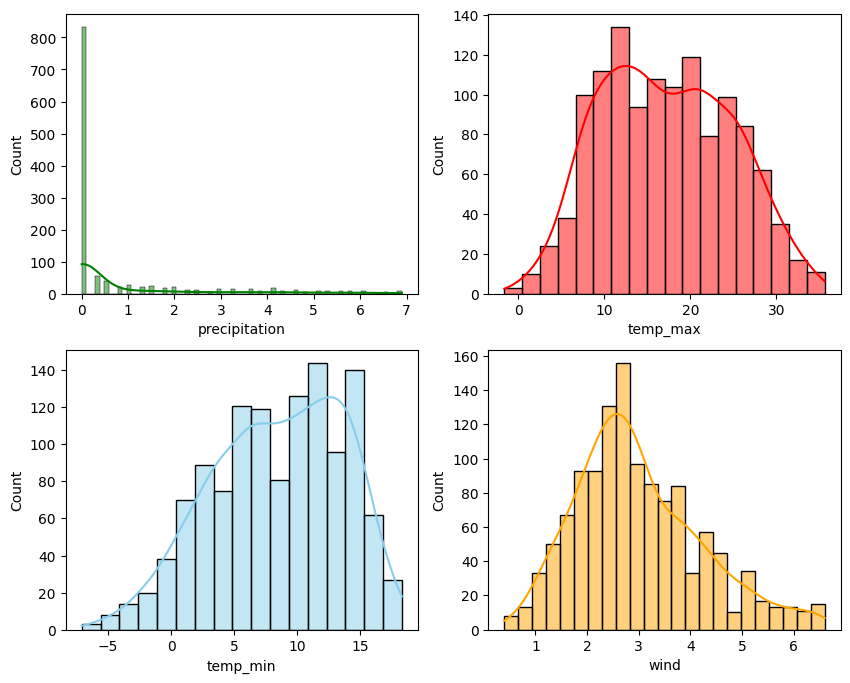

In [104]:
fig,axs=plt.subplots(2,2,figsize=(10,8))
sns.histplot(data=df,x="precipitation",kde=True,ax=axs[0,0],color='green')
sns.histplot(data=df,x="temp_max",kde=True,ax=axs[0,1],color='red')
sns.histplot(data=df,x="temp_min",kde=True,ax=axs[1,0],color='skyblue')
sns.histplot(data=df,x="wind",kde=True,ax=axs[1,1],color='orange')

<Axes: xlabel='wind'>

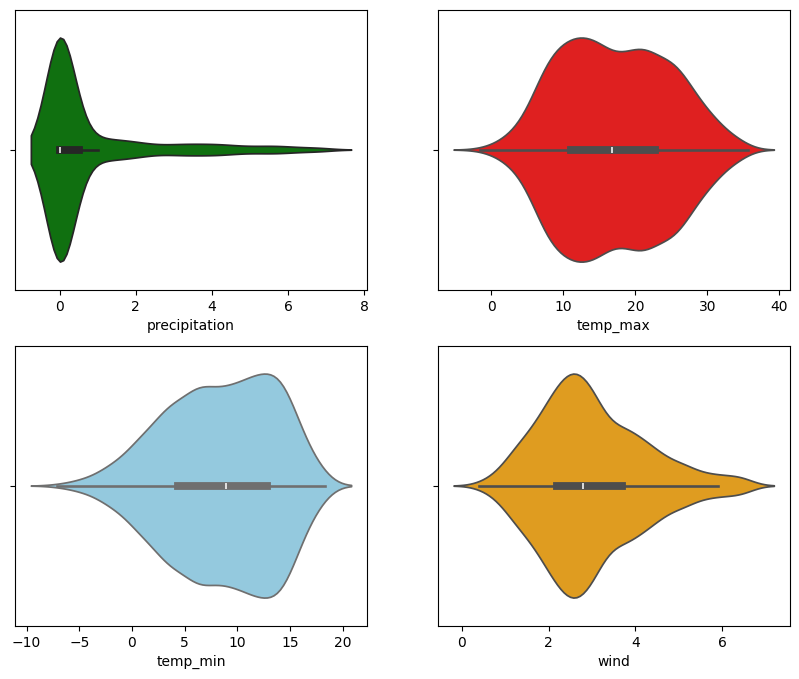

In [105]:
# Violin plot
fig, axes = plt.subplots(2,2, figsize=(10,8))
sns.violinplot(data=df, x='precipitation', ax=axes[0,0], color='green')
sns.violinplot(data=df, x='temp_max', ax=axes[0,1], color='red')
sns.violinplot(data=df, x='temp_min', ax=axes[1,0], color='skyblue')
sns.violinplot(data=df, x='wind', ax=axes[1,1], color='orange')

In [111]:
df.head()

,precipitation,temp_max,temp_min,wind,weather
0,0.0,12.8,5.0,4.7,drizzle
2,0.8,11.7,7.2,2.3,rain
4,1.3,8.9,2.8,6.1,rain
5,2.5,4.4,2.2,2.2,rain
6,0.0,7.2,2.8,2.3,rain


# Scaling 'weather' variable using LableEncoder

In [112]:
from sklearn.preprocessing import LabelEncoder

In [113]:
lc = LabelEncoder()
lc.fit_transform(df['weather'])

array([0, 2, 2, ..., 1, 4, 4], shape=(1233,))

In [129]:
df['weather_enc'] = lc.fit_transform(df.weather)
df

,precipitation,temp_max,temp_min,wind,weather,weather_enc
0,0.0,12.8,5.0,4.7,drizzle,0
2,0.8,11.7,7.2,2.3,rain,2
4,1.3,8.9,2.8,6.1,rain,2
5,2.5,4.4,2.2,2.2,rain,2
6,0.0,7.2,2.8,2.3,rain,2
...,...,...,...,...,...,...
1455,0.0,4.4,0.0,2.5,sun,4
1457,1.5,5.0,1.7,1.3,rain,2
1458,0.0,7.2,0.6,2.6,fog,1
1459,0.0,5.6,-1.0,3.4,sun,4


In [115]:
df.weather_enc.unique()

array([0, 2, 4, 3, 1])

In [128]:
df.weather.unique()

<ArrowStringArray>
['drizzle', 'rain', 'sun', 'snow', 'fog']
Length: 5, dtype: str

# split the dataset into Dependent and independent variable

In [116]:
df.info()

<class 'pandas.DataFrame'>
Index: 1233 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   precipitation  1233 non-null   float64
 1   temp_max       1233 non-null   float64
 2   temp_min       1233 non-null   float64
 3   wind           1233 non-null   float64
 4   weather        1233 non-null   str    
 5   weather_enc    1233 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 71.8 KB


In [117]:
X = df[['precipitation','temp_max','temp_min','wind']]
y = df['weather_enc']

In [118]:
from sklearn.model_selection import train_test_split

In [119]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# ALGORITHMS AND MODEL TRAINING


In [121]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [122]:
models = {
    'LogisticRegression': LogisticRegression(),
    'DecisionTreeClassifier': DecisionTreeClassifier(),
    'RandomForestClassifier': RandomForestClassifier(),
    'GradientBoostingClassifier': GradientBoostingClassifier(),
    'SVM': SVC(),
    'KNeighborsClassifier': KNeighborsClassifier(),
}

In [133]:
for name, model in models.items():
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test,y_pred)
    score = model.score(X_test,y_test)*100
    print(f"{name}")
    print(f"Accuracy score: {acc}")
    print(f"model score : {score}")
 
    print("input the model to predict the weather")
    input=[[0.0,4.4,0.0,2.5	]]
    pred = model.predict(input)
    print("The weather is: ") # ['drizzle', 'rain', 'sun', 'snow', 'fog'] array([0, 2, 4, 3, 1])
    if pred == 0:
        print('Drizzle')
    elif pred ==1:
        print('Fog')
    elif pred ==2:
        print('Rain')
    elif pred == 3:
        print('Snow')
    else:
        print('Sun')

    print("-----------------")

D:\my project\codeit_datascience\data_science\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
D:\my project\codeit_datascience\data_science\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
D:\my project\codeit_datascience\data_science\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but Decisi

LogisticRegression
Accuracy score: 0.8421052631578947
model score : 84.21052631578947
input the model to predict the weather
The weather is: 
Sun
-----------------
DecisionTreeClassifier
Accuracy score: 0.7530364372469636
model score : 75.30364372469636
input the model to predict the weather
The weather is: 
Sun
-----------------
RandomForestClassifier
Accuracy score: 0.8097165991902834
model score : 80.97165991902834
input the model to predict the weather
The weather is: 
Sun
-----------------


D:\my project\codeit_datascience\data_science\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


GradientBoostingClassifier
Accuracy score: 0.8259109311740891
model score : 82.5910931174089
input the model to predict the weather
The weather is: 
Sun
-----------------
SVM
Accuracy score: 0.7408906882591093
model score : 74.08906882591093
input the model to predict the weather
The weather is: 
Sun
-----------------
KNeighborsClassifier
Accuracy score: 0.7044534412955465
model score : 70.44534412955466
input the model to predict the weather
The weather is: 
Drizzle
-----------------


D:\my project\codeit_datascience\data_science\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
D:\my project\codeit_datascience\data_science\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
D:\my project\codeit_datascience\data_science\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
